In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [3]:
samples = np.load(f"../../../../output/age_depth_rethinking/samples_{config_str}.npy")
energy_values = np.load(f"../../../../output/age_depth_rethinking/energy_values_{config_str}.npy")
bias_values = np.load(f"../../../../output/age_depth_rethinking/bias_values_{config_str}.npy")
resampled_samples = np.load(f"../../../../output/age_depth_rethinking/resampsamp_{config_str}.npy")
print(np.shape(samples))

(4, 10000, 10)


In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [5]:
print(energy_values)

[[139.72207485  12.069371    16.37725314 ...  28.79343088  29.03162084
   26.53398289]
 [180.99235549  76.00289054  76.00289054 ...  91.46347236  90.23388719
   89.84934004]
 [196.13638268  75.5900071   90.39855209 ...  84.43876418  87.07754394
   81.63308585]
 [180.71661038  46.40203985  46.40203985 ...  27.79921859  28.01971612
   27.84318777]]


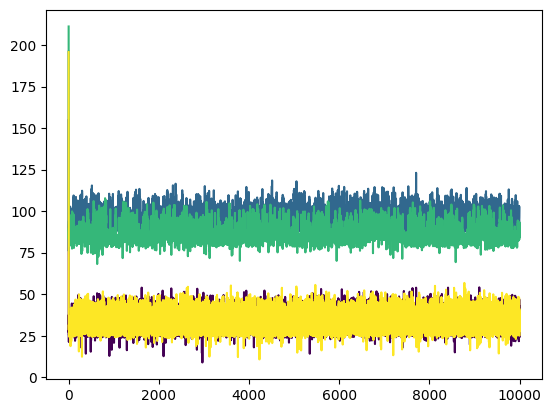

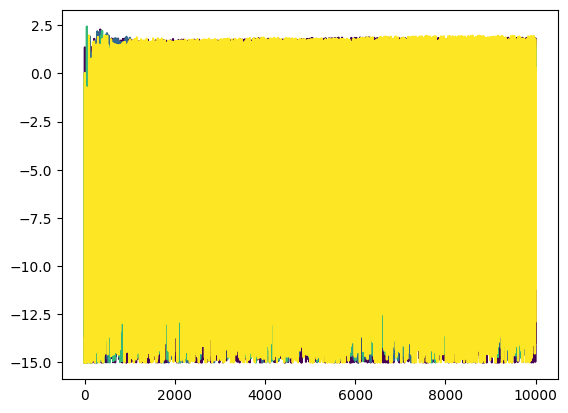

In [6]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:] - bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

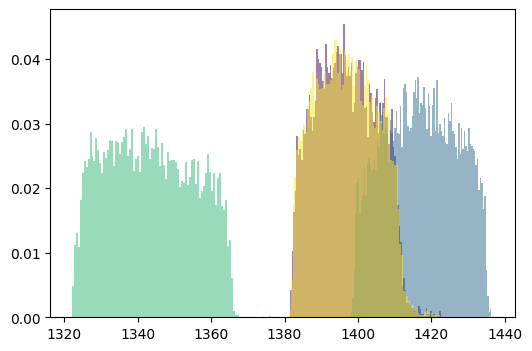

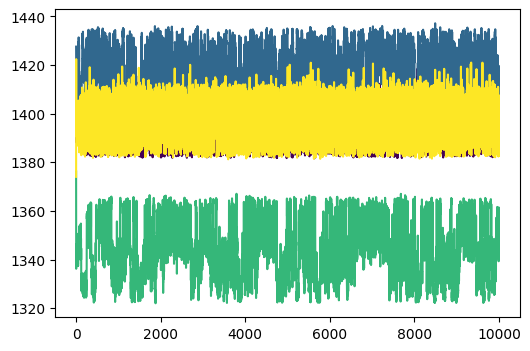

In [7]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

In [8]:
resampled_samples = resampled_samples[:,::100,:]

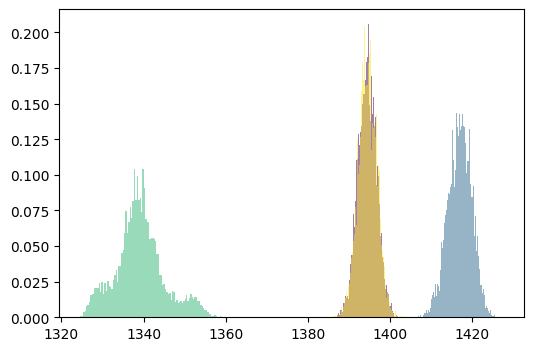

In [8]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

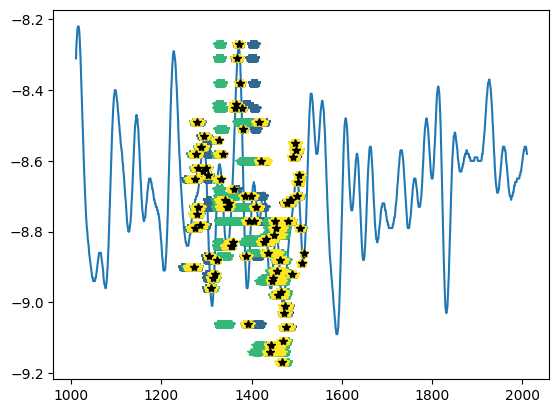

In [9]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [11]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]   9.52  0.51    8.64     9.82       0.07     0.06     48.16     48.16   
x[1]  13.22  1.63   10.50    16.13       0.24     0.16     48.16     32.00   
x[2]   5.73  2.62    2.08    10.16       0.38     0.23     48.16     48.16   
x[3]  16.04  8.67    7.15    30.45       1.25     0.68     48.16     32.00   
x[4]  25.00  4.35   21.39    32.12       0.63     0.33     48.16     32.00   
x[5]  11.00  2.71    7.32    14.68       0.39     0.21     48.16     48.16   
x[6]  13.37  1.32   11.81    15.68       0.19     0.20     48.16     48.16   
x[7]  14.61  2.30   11.48    16.84       0.33     0.12     48.16     48.16   
x[8]  10.72  6.26    0.30    15.51       0.90     0.49     48.16     48.16   
x[9]   3.39  1.90    1.55     5.68       0.27     0.15     48.16     48.16   

      r_hat  
x[0]   1.71  
x[1]   1.32  
x[2]   1.45  
x[3]   2.90  
x[4]   2.10  
x[5]   2.08  
x[6]   1.38  
x[7]   1.54  
x[8]   2.63  
x

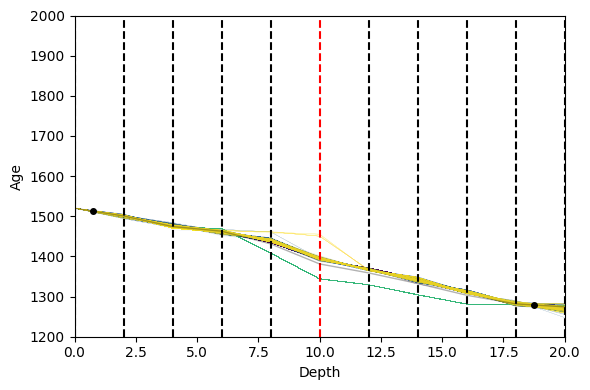

In [15]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    if i != config["pidx"]:
        ax.axvline(x=c, color='k', linestyle='--')
    else:
        ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()